# Set Up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
# Stuff needed for the Horizontal Barchart
pres_state = pd.read_csv('president_state.csv')
pres_state['total_votes'] = pd.to_numeric(pres_state['total_votes'], errors='coerce')
pres_state = pres_state[pres_state['state'] != 'United States']
pres_state['votes_in_millions'] = pres_state['total_votes'] / 1000000

pres_cc = pd.read_csv('president_county_candidate.csv')

# Horizontal Bar Chart of Total Votes per State

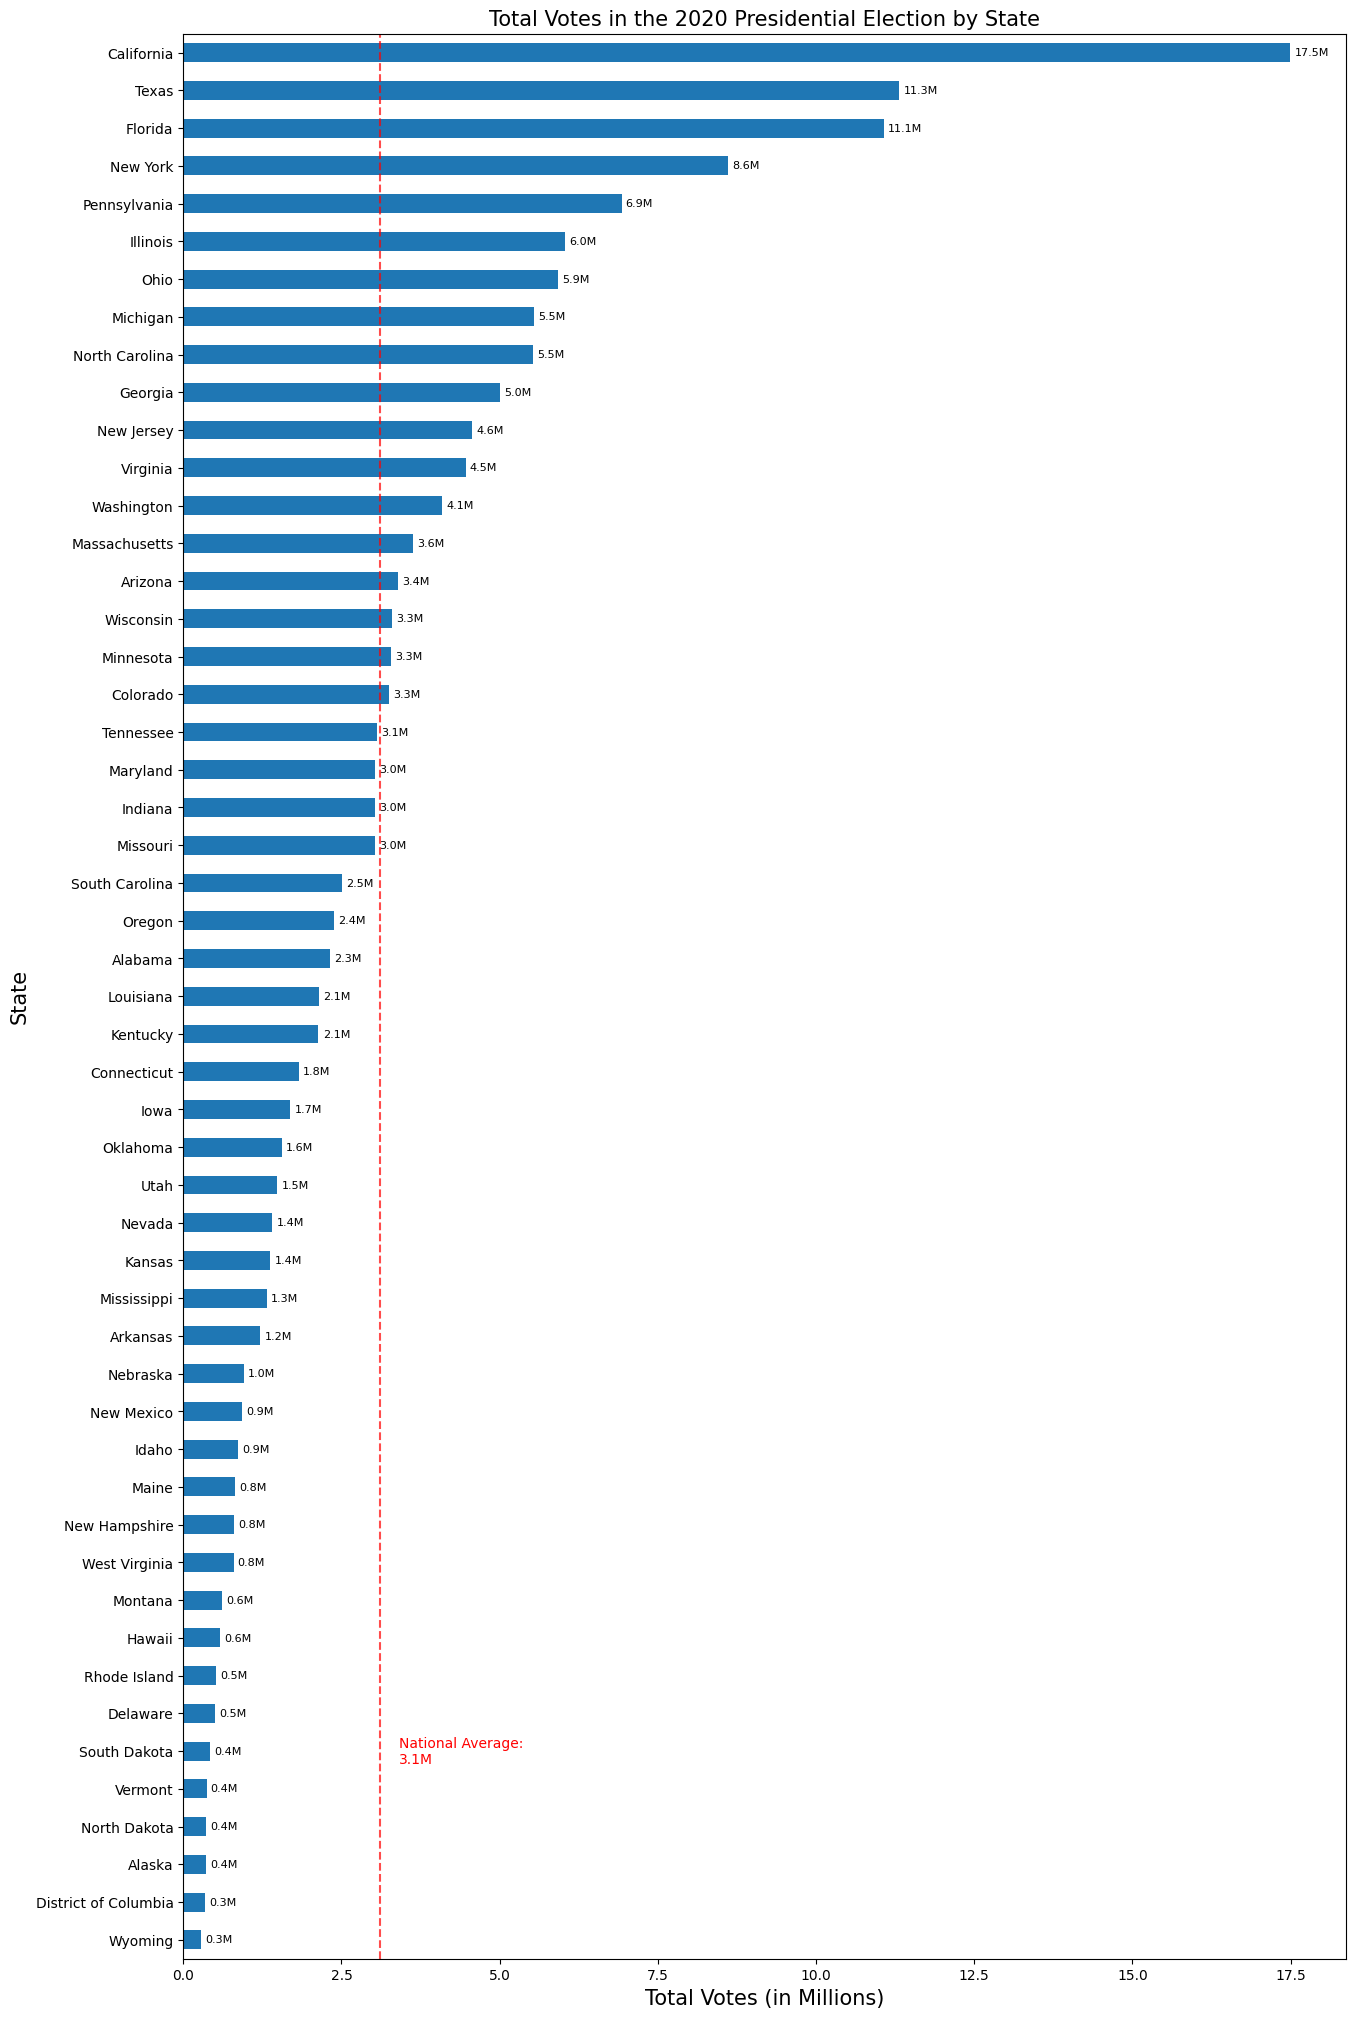

In [64]:
pres_state = pres_state.sort_values(by='votes_in_millions', ascending=True)
ax = pres_state.plot(kind = 'barh', x = 'state', y = 'votes_in_millions', legend = False, figsize = (15,25))

plt.title('Total Votes in the 2020 Presidential Election by State', size = 15)
plt.xlabel('Total Votes (in Millions)', size = 15)
plt.ylabel('State', size = 15)

# Adds the average votes line
avg_votes = pres_state['votes_in_millions'].mean()
ax.axvline(avg_votes, color='red', linestyle='--', alpha = 0.7)
ax.text(avg_votes + 0.3, 5, f'National Average:\n{avg_votes:.1f}M', color='red', va='center')

# Adds the total votes at the end of the bar so it's so much easier to read 
labels = [f'{v/1000000:.1f}M' for v in pres_state['total_votes']]
ax.bar_label(ax.containers[0], labels=labels, padding=3, fontsize=8, color='black')

plt.show()

# Horizontal Bar Chart of Election Results in Top 10 States (in Millions)

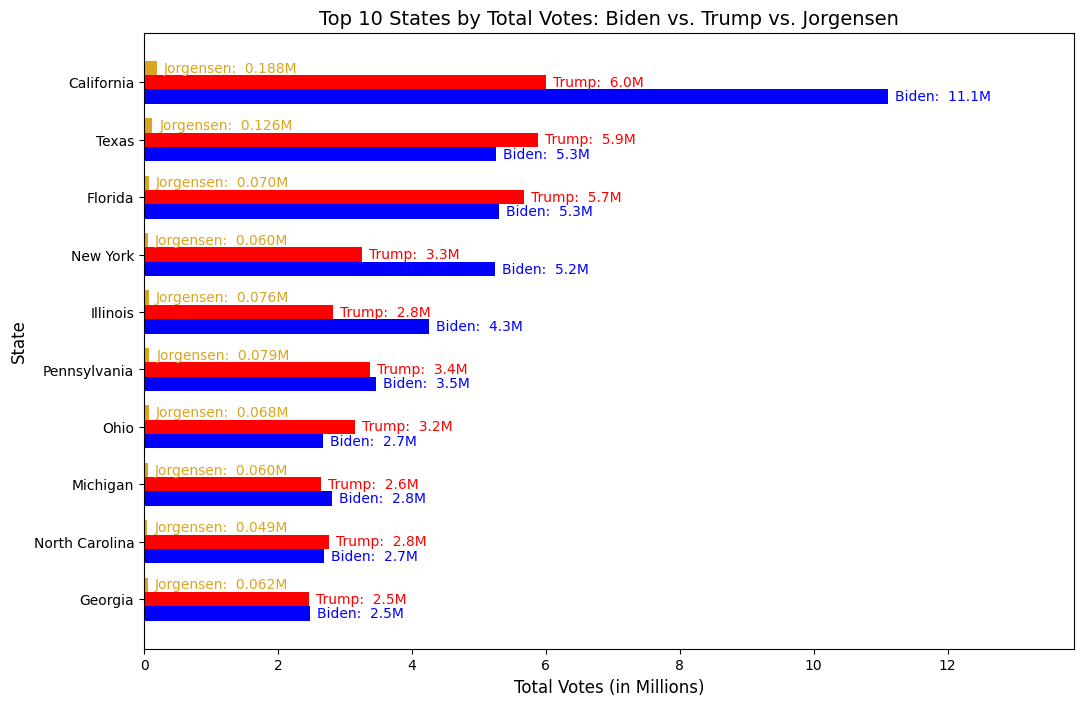

In [102]:
state_cand = pres_cc.groupby(['state', 'candidate'])['total_votes'].sum().reset_index()
top = state_cand[state_cand['candidate'].isin(['Joe Biden', 'Donald Trump', 'Jo Jorgensen'])]

# Data cleaning to get nicer data
pivot_top = top.pivot(index = 'state', columns = 'candidate', values = 'total_votes').reset_index()
pivot_top['Total'] = pivot_top['Donald Trump'] + pivot_top['Joe Biden'] + pivot_top['Jo Jorgensen']
top_states = pivot_top.sort_values(by = 'Total', ascending = False).head(10)
top_states = top_states.sort_values(by = 'Total', ascending = True)

# Graphing 
fig, ax = plt.subplots(figsize=(12, 8))
y = np.arange(len(top_states))
height = 0.25
biden_votes = top_states['Joe Biden']/1000000
trump_votes = top_states['Donald Trump']/1000000
jo_votes = top_states['Jo Jorgensen']/1000000

rects1 = ax.barh(y - height, biden_votes, height, color = 'blue')
rects2 = ax.barh(y, trump_votes, height, color = 'red')
rects3 = ax.barh(y + height, jo_votes, height, color = 'goldenrod')

plt.xlabel('Total Votes (in Millions)', size = 12)
plt.ylabel('State', size = 12)
plt.title('Top 10 States by Total Votes: Biden vs. Trump vs. Jorgensen', size = 14)
ax.set_yticks(y)
ax.set_yticklabels(top_states['state'])

# Label each bar 
biden_label = [f"Biden: {v: .1f}M" for v in biden_votes]
trump_label = [f"Trump: {v: .1f}M" for v in trump_votes]
jo_label = [f"Jorgensen: {v: .3f}M" for v in jo_votes]

ax.bar_label(rects1, labels = biden_label, padding=5, color='blue', fontsize=10)
ax.bar_label(rects2, labels = trump_label, padding=5, color='red', fontsize=10)
ax.bar_label(rects3, labels = jo_label, padding=5, color='goldenrod', fontsize=10)

# Specifically asked for AI help to keep the labels within the graph 
max_val = max(biden_votes.max(), trump_votes.max(), jo_votes.max())
ax.set_xlim(0, max_val * 1.25)

plt.show()

# Table of 2020 Election Results in Top 10 States

In [134]:
# Copy and paste from previous graph 
state_cand = pres_cc.groupby(['state', 'candidate'])['total_votes'].sum().reset_index()
top = state_cand[state_cand['candidate'].isin(['Joe Biden', 'Donald Trump', 'Jo Jorgensen'])]

pivot_top = top.pivot(index = 'state', columns = 'candidate', values = 'total_votes').reset_index()
pivot_top['Total'] = pivot_top['Donald Trump'] + pivot_top['Joe Biden'] + pivot_top['Jo Jorgensen']
top_states = pivot_top.sort_values(by = 'Total', ascending = False).head(10)
top_states = top_states.sort_values(by = 'Total', ascending = False)

# top_states.head(10)

# Creating the Chart
top_chart = pd.DataFrame({
    'State': ['California', 'Texas', 'Florida', 'New York', 'Illinois', 'Pennsylvania', 'Ohio', 'Michigan', 'North Carolina', 'Georgia'],
    'Donald Trump': [6005961, 5890347, 5668731, 3250230, 2823926, 3378263, 3154834, 2649852, 2758773, 2461854],
    '% of Trump Votes': [34.709295, 52.239228, 51.365346, 37.993923, 39.477795, 48.835887, 53.457556, 48.054422, 50.234925, 49.259582],    
    'Joe Biden': [11109764, 5259126, 5297045, 5244006, 4253153, 3459923, 2679165, 2804040, 2684292, 2473633],
    '% of Biden Votes': [64.204891, 46.641171, 47.997436, 61.300387, 59.458038, 50.016357, 45.397511, 50.850584, 48.878689, 49.495269], 
    'Jo Jorgensen': [187885, 126243, 70324, 60369, 76122, 79397, 67569, 60381, 48678, 62229],
    '% of Jorgensen Votes': [1.085814, 1.119601, 0.637218, 0.705690, 1.064167, 1.147756, 1.144933, 1.094995, 0.886385, 1.245149],  
    'Total Votes': [17303610, 11275716, 11036100, 8554605, 7153201, 6917583, 5901568, 5514273, 5491743, 4997716]
})

# Formatting the chart 
styled = (
    top_chart.style
    .format({'Donald Trump':'{:,.0f}', 'Joe Biden':'{:,.0f}', 'Joe Jorgensen':'{:,.0f}', 'Total Votes':'{:,.0f}', '% of Trump Votes':'{:.1f}%', '% of Biden Votes':'{:.1f}%', '% of Jorgensen Votes':'{:.1f}%'})
    .set_caption('2020 Election Results in Top 10 Voting States')
    )

styled

,State,Donald Trump,% of Trump Votes,Joe Biden,% of Biden Votes,Jo Jorgensen,% of Jorgensen Votes,Total Votes
0,California,"6,005,961",34.7%,"11,109,764",64.2%,187885,1.1%,"17,303,610"
1,Texas,"5,890,347",52.2%,"5,259,126",46.6%,126243,1.1%,"11,275,716"
2,Florida,"5,668,731",51.4%,"5,297,045",48.0%,70324,0.6%,"11,036,100"
3,New York,"3,250,230",38.0%,"5,244,006",61.3%,60369,0.7%,"8,554,605"
4,Illinois,"2,823,926",39.5%,"4,253,153",59.5%,76122,1.1%,"7,153,201"
5,Pennsylvania,"3,378,263",48.8%,"3,459,923",50.0%,79397,1.1%,"6,917,583"
6,Ohio,"3,154,834",53.5%,"2,679,165",45.4%,67569,1.1%,"5,901,568"
7,Michigan,"2,649,852",48.1%,"2,804,040",50.9%,60381,1.1%,"5,514,273"
8,North Carolina,"2,758,773",50.2%,"2,684,292",48.9%,48678,0.9%,"5,491,743"
9,Georgia,"2,461,854",49.3%,"2,473,633",49.5%,62229,1.2%,"4,997,716"


# Summary 
I chose the horizontal bar chart for both my visualization and my labeled chart because it was the most legible, given how many things I wanted to show on the same chart (state, voting totals, party, candidates). For the first horizontal bar chart, I chose to annotate the total of each bar because the x-axis is far away from the states at the top of the graph, making it slightly inconvenient to read. I think this choice also makes the overall graph easier to read, so there is no guessing with total votes, especially closer to the bottom of the bar chart when the differences between less populated states get harder to distinguish. The addition of the vertical average line was a nice touch, as it further shows the difference between state populations and how much influence more populous states can have on election results. For my second bar chart, I knew this one would be more complicated, so I tried to make it easier to understand. I distinguished the candidates by their party colors, added the total votes for each candidate at the end of the bar, and labeled the candidate's name as well to get rid of the Legend. I also decided to limit it to the top 10 states (based on total vote number), to make it less intense. I used the same data as the second horizontal bar chart to make my formatted table, but I included the percentage of the vote for each state that each candidate got within that state. These columns make it much easier to understand how close the election results were and visualize who won the most amount of votes in each state. 